In [2]:
!pip install deepface

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.2/169.2 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 82.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 95.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 5.5 MB/s eta 0:00:00


In [6]:
from deepface import DeepFace
import matplotlib.pyplot as plt
import pandas as pd
import cv2

In [7]:
# Image path
IMAGE_PATH = "/content/winter.jpg"
DATABASE_PATH = "/content/"

In [8]:
def find_related_faces(img_path, db_path):
    """Find similar faces in the database."""
    df = DeepFace.find(
        img_path=img_path,
        db_path=db_path,
        model_name="Facenet",
        detector_backend="retinaface",
        enforce_detection=False
    )
    return df

In [9]:
def analyze_faces(image_paths):
    """Analyze face attributes."""
    results = DeepFace.analyze(
        img_path=image_paths,
        actions=["emotion", "age", "gender", "race"],
        detector_backend="retinaface",
        enforce_detection=False
    )
    return results

In [10]:
def extract_attributes(results):
    """Extract attributes from analysis results."""
    emotions = []
    ages = []
    genders = []
    races = []

    for image in results:
        for face in image:
            emotions.append(face["dominant_emotion"])
            ages.append(face["age"])
            genders.append(face["dominant_gender"])
            races.append(face["dominant_race"])

    return emotions, ages, genders, races

In [11]:
def load_images(image_paths):
    """Load images using OpenCV."""
    images = []

    for path in image_paths:
        img = cv2.imread(path)
        images.append(img)

    return images

In [12]:
def show_result(image, emotion, age, gender, race):
    """Display image with attributes."""
    rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.imshow(rgb_image)
    plt.title(
        f"Emotion: {emotion} | Age: {age} | "
        f"Gender: {gender} | Race: {race}"
    )
    plt.axis("off")
    plt.show()

In [13]:
def main():
    """Main function."""
    df_list = find_related_faces(IMAGE_PATH, DATABASE_PATH)

    # Check if df_list is empty
    if not df_list:
        print("No related faces found.")
        return

    # DeepFace.find returns a list, the actual DataFrame is the first element
    df = pd.DataFrame(df_list[0])

    # Check if the DataFrame is empty
    if df.empty:
        print("No related faces found in the DataFrame.")
        return

    image_paths = list(df["identity"])

    results = analyze_faces(image_paths)

    # Check if results are empty
    if not results:
        print("No face analysis results found.")
        return

    emotions, ages, genders, races = extract_attributes(results)

    images = load_images(image_paths)

    if images:
        show_result(
            images[0],
            emotions[0],
            ages[0],
            genders[0],
            races[0]
        )
    else:
        print("No images could be loaded.")

26-02-21 21:57:48 - Searching /content/winter.jpg in 6 length datastore
26-02-21 21:57:49 - find function duration 0.43016481399536133 seconds


Action: race: 100%|██████████| 4/4 [00:00<00:00, 48.25it/s]


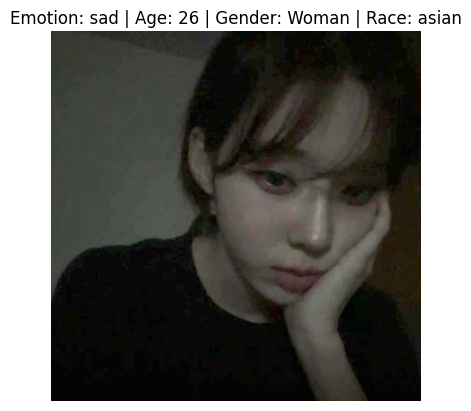

In [14]:
if __name__ == "__main__":
    main()